# Workflows and agents with DeepSeek

This notebook mirrors the workflow and agent patterns from the LangGraph docs page: https://docs.langchain.com/oss/python/langgraph/workflows-agents.

The structure follows the page: LLM augmentations, prompt chaining, parallelization, routing, orchestrator-worker, evaluator-optimizer, a tool-calling agent, and a `ToolNode` example. The intentional difference is the model provider setup: the docs initialize Anthropic, while this notebook uses DeepSeek through the OpenAI-compatible `ChatOpenAI` client.


## Setup

Use the `langgraph-deepseek` conda environment as this notebook kernel.

If the Jupyter kernel has not been registered yet, run this once in your terminal:

```bash
conda run -n langgraph-deepseek python -m ipykernel install --user --name langgraph-deepseek --display-name langgraph-deepseek
```

If any dependency is missing, uncomment and run the install cell below.


In [9]:
# %pip install -U langgraph langchain langchain-openai pydantic


## Register the DeepSeek API key

This notebook sets `DEEPSEEK_API_KEY` directly in the current notebook process. `DEEPSEEK_MODEL` defaults to the same model used by `examples/email/thinking_in_langgraph_email.ipynb` and can be overridden before running the notebook.


In [10]:
import os
os.environ["DEEPSEEK_API_KEY"] = "sk-43fd8b3b130f439e8c43b6e4361c8ec6"

os.environ.setdefault("DEEPSEEK_BASE_URL", "https://api.deepseek.com")
os.environ.setdefault("DEEPSEEK_MODEL", "deepseek-v4-flash")


'deepseek-v4-flash'

In [11]:
from __future__ import annotations

import operator
from typing import Annotated, List, Literal

from IPython.display import Image, Markdown, display
from langchain.messages import HumanMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
from pydantic import BaseModel, Field
from typing_extensions import TypedDict


## LLM

The docs page initializes an Anthropic chat model. DeepSeek exposes an OpenAI-compatible chat-completions API, so the model-specific change is the `model`, `base_url`, and API key configuration.


In [12]:
llm = ChatOpenAI(
    model=os.environ["DEEPSEEK_MODEL"],
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_BASE_URL"],
    temperature=0,
)


## LLMs and augmentations

Workflows and agentic systems usually start with an LLM plus augmentations. The first example asks DeepSeek for structured JSON output. The second binds a Python function as a tool.


In [17]:
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


structured_llm = llm.with_structured_output(SearchQuery, method="json_mode")

output = structured_llm.invoke(
    """
    Return JSON with keys `search_query` and `justification`.
    User request: How does Calcium CT score relate to high cholesterol?
    """
)
output


SearchQuery(search_query='Calcium CT score high cholesterol relationship', justification="This query directly addresses the user's question about the connection between coronary calcium score and high cholesterol, focusing on studies or medical explanations for how they are related.")

In [15]:
def multiply(a: int, b: int) -> int:
    return a * b


llm_with_multiply_tool = llm.bind_tools([multiply])
msg = llm_with_multiply_tool.invoke("What is 2 times 3?")
msg.tool_calls


[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_00_RGADyrXiN7hF3SrOwuB48982',
  'type': 'tool_call'}]

## Prompt chaining

Prompt chaining runs each LLM call after the previous step. This example generates a joke, conditionally improves it, and optionally adds a final polish step.


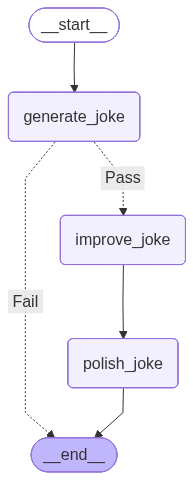

In [26]:
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


def generate_joke(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


workflow = StateGraph(State)
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke",      # 1. 源节点：从哪个节点出发
    check_punchline,      # 2. 路由函数：节点执行完后调用它来决定走哪条边
    {"Pass": "improve_joke", "Fail": END},  # 3. 映射表：路由函数的返回值 → 目标节点
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

chain = workflow.compile()
display(Image(chain.get_graph().draw_mermaid_png()))


In [ ]:
# 用于演示的流式输出（可选）
# for step in chain.stream({"topic": "cats"}, stream_mode="updates"):
#     print(step)
#     print("---")
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")

if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")
    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])


{'generate_joke': {'joke': "Why don't cats play poker in the jungle? Too many cheetahs."}}
---
{'improve_joke': {'improved_joke': "Why don't cats play poker in the jungle? Too many cheetahs—they're always marking the deck."}}
---
{'polish_joke': {'final_joke': "Why don't cats play poker in the jungle? Too many cheetahs—they're always marking the deck. But the surprising twist? It's actually because the cheetahs themselves are always spotted, so they can never bluff—everyone knows what they've got!"}}
---
Initial joke:
Why did the cat sit on the computer? To keep an eye on the mouse.

--- --- ---

Improved joke:
Why did the cat sit on the computer? To keep an eye on the mouse—and to byte into the action!

--- --- ---

Final joke:
Why did the cat sit on the computer? To keep an eye on the mouse—and to byte into the action! But here’s the twist: the cat was actually a cybersecurity expert, and the “mouse” was a hacker trying to install a keylogger. The cat wasn’t just watching—it was runn

## Parallelization

Parallelization runs independent subtasks at the same time and aggregates their outputs. Here, DeepSeek writes a joke, story, and poem about the same topic in parallel.


In [ ]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


def call_llm_1(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


parallel_builder = StateGraph(State)
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

parallel_workflow = parallel_builder.compile()
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))


In [ ]:
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])


## Routing

Routing workflows classify input and send it to the right downstream node. This example routes the request to a story, joke, or poem node.


In [ ]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


router = llm.with_structured_output(Route, method="json_mode")


class State(TypedDict):
    input: str
    decision: str
    output: str


def llm_call_1(state: State):
    """Write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""
    decision = router.invoke(
        [
            SystemMessage(
                content=(
                    "Route the input to story, joke, or poem based on the user's request. "
                    "Return JSON with exactly one key, `step`, whose value is `story`, `joke`, or `poem`."
                )
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}


def route_decision(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


router_builder = StateGraph(State)
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

router_workflow = router_builder.compile()
display(Image(router_workflow.get_graph().draw_mermaid_png()))


In [ ]:
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])


## Orchestrator-worker

The orchestrator-worker pattern lets the graph create workers dynamically. The orchestrator plans report sections, then `Send` starts one worker per section and the reducer combines their outputs.


In [ ]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report.")
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section."
    )


class Sections(BaseModel):
    sections: List[Section] = Field(description="Sections of the report.")


planner = llm.with_structured_output(Sections, method="json_mode")


class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""
    report_sections = planner.invoke(
        [
            SystemMessage(
                content=(
                    "Generate a plan for the report. Return JSON with a `sections` array. "
                    "Each item must include `name` and `description`."
                )
            ),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )
    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""
    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Write a report section following the provided name and description. "
                    "Include no preamble for each section. Use markdown formatting."
                )
            ),
            HumanMessage(
                content=(
                    f"Here is the section name: {state['section'].name} and "
                    f"description: {state['section'].description}"
                )
            ),
        ]
    )
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""
    completed_sections = state["completed_sections"]
    completed_report_sections = "\n\n---\n\n".join(completed_sections)
    return {"final_report": completed_report_sections}


def assign_workers(state: State):
    """Assign a worker to each section in the plan"""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


orchestrator_worker_builder = StateGraph(State)
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"],
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

orchestrator_worker = orchestrator_worker_builder.compile()
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [ ]:
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})
Markdown(state["final_report"])


## Evaluator-optimizer

An evaluator-optimizer loop generates an answer, grades it, and routes back for improvement when needed. This follows the docs page's open-ended loop, which continues until the evaluator accepts the output.


In [ ]:
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not."
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it."
    )


evaluator = llm.with_structured_output(Feedback, method="json_mode")


class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


def llm_call_generator(state: State):
    """LLM generates a joke"""
    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""
    grade = evaluator.invoke(
        f"""
        Return JSON with keys `grade` and `feedback`.
        `grade` must be either `funny` or `not funny`.
        Grade this joke: {state['joke']}
        """
    )
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""
    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


optimizer_builder = StateGraph(State)
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

optimizer_workflow = optimizer_builder.compile()
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))


In [ ]:
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])


## Agents

Agents use an LLM in a feedback loop with tools. This example defines arithmetic tools, lets DeepSeek decide whether to call one, executes the tool call, and loops until the model returns a final answer.


In [ ]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.
    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)


def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tool_node"
    return END


agent_builder = StateGraph(MessagesState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for message in messages["messages"]:
    message.pretty_print()


## ToolNode

`ToolNode` is a prebuilt node that executes tools in LangGraph workflows. It handles parallel tool execution, error handling, and state injection automatically. Use `ToolNode` when you need fine-grained control over how your graph executes tools. This is the building block that powers tool execution in many LangGraph agent patterns.


In [ ]:
@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"


@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))


builder = StateGraph(MessagesState)
builder.add_node("tools", ToolNode([search, calculator]))
builder.add_edge(START, "tools")
builder.add_edge("tools", END)
graph = builder.compile()
